<a href="https://colab.research.google.com/github/Deyv0R/repo1/blob/main/%D0%9A%D0%B8%D1%8F%D0%BD%D0%B8%D1%86%D1%8F_%D0%9B%D1%804.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Перші 5 рядків:
                    month  america_tropical_interpretive_center  avila_adobe  \
0  01/01/2014 12:00:00 AM                                  6602        24778   
1  02/01/2014 12:00:00 AM                                  5029        18976   
2  03/01/2014 12:00:00 AM                                  8129        25231   
3  04/01/2014 12:00:00 AM                                  2824        26989   
4  05/01/2014 12:00:00 AM                                 10694        36883   

   chinese_american_museum  gateway_to_nature_center  firehouse_museum  \
0                     1581                       NaN              4486   
1                     1785                       NaN              4172   
2                     3229                       NaN              7082   
3                     2129                       NaN              6756   
4                     3676                       NaN             10858   

   hellman_quon  iamla  pico_house  visitor_center/_el_tra

/tmp/ipykernel_19482/901962867.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['month'] = pd.to_datetime(df['month'])


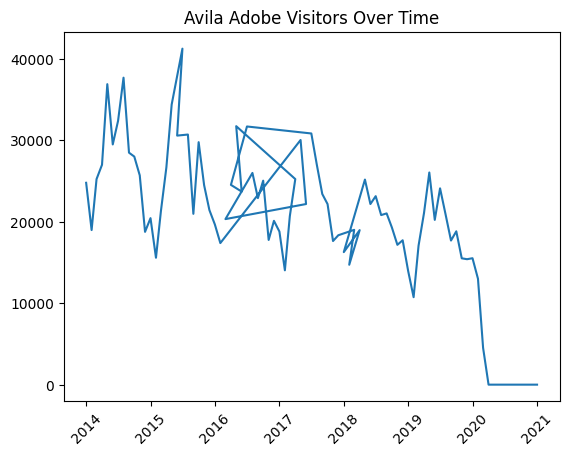

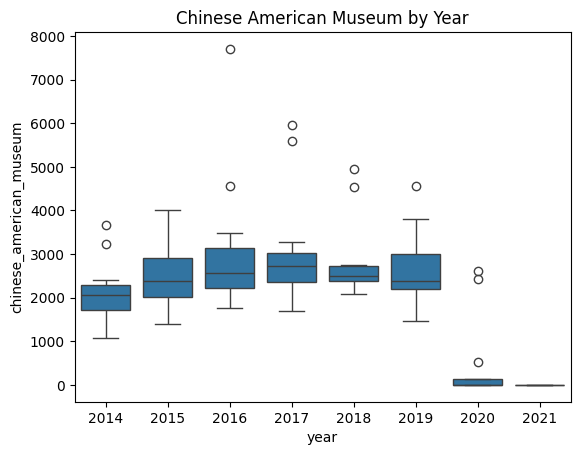

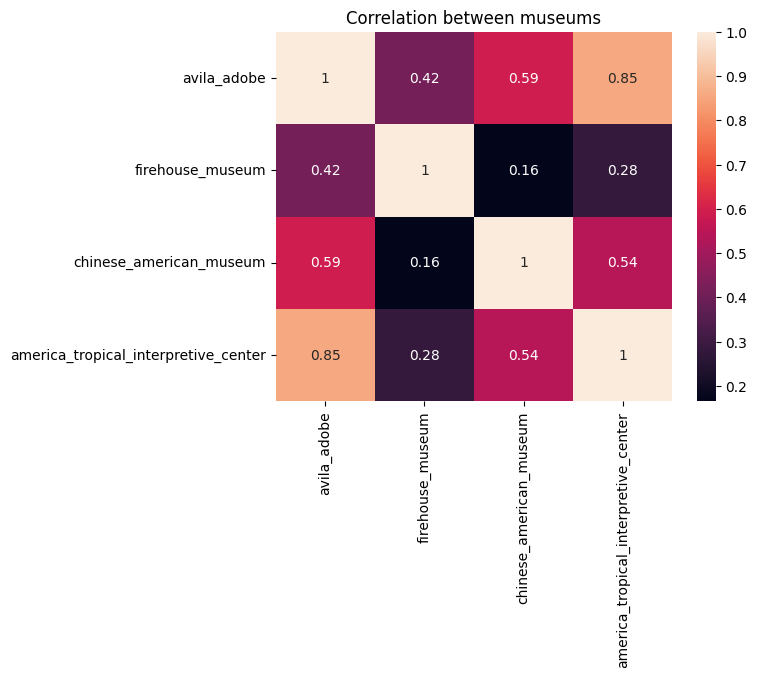

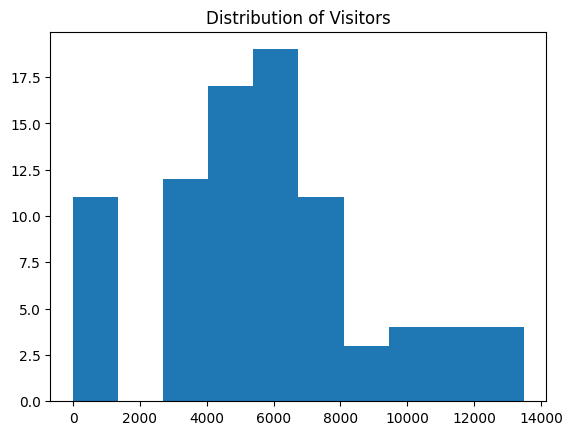

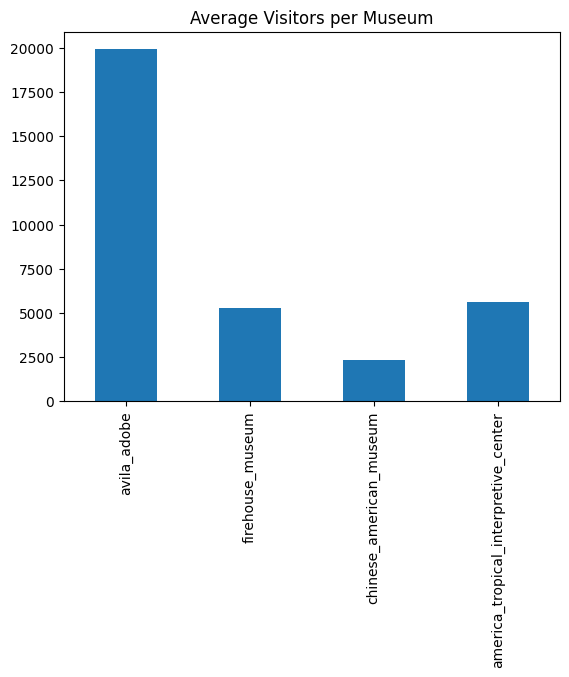

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Завантаження даних
# ---------------------------
df = pd.read_csv('/content/drive/MyDrive/КСВД/Museum_Visitors.csv')

# ---------------------------
# 2. Очистка назв колонок
# ---------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# ---------------------------
# 3. Перші 5 рядків
# ---------------------------
print("Перші 5 рядків:")
print(df.head())

# ---------------------------
# 4. Попередній аналіз
# ---------------------------
print("\nРозмір датасету:", df.shape)

print("\nТипи даних:")
print(df.dtypes)

print("\nПропуски:")
print(df.isnull().sum())

# ---------------------------
# 5. Дублікати
# ---------------------------
print("\nДублікати:", df.duplicated().sum())

df = df.drop_duplicates()

print("Розмір після видалення дублікатів:", df.shape)

# ---------------------------
# 6. Робота з датою (У ТЕБЕ 'month')
# ---------------------------
df['month'] = pd.to_datetime(df['month'])

df['year'] = df['month'].dt.year
df['month_name'] = df['month'].dt.month_name()

print("\nРоки в датасеті:")
print(df['year'].unique())

# ---------------------------
# 7. Залишаємо потрібні музеї
# ---------------------------
df = df[['month', 'year', 'month_name',
         'avila_adobe',
         'firehouse_museum',
         'chinese_american_museum',
         'america_tropical_interpretive_center']]

# ---------------------------
# 8. Середня відвідуваність
# ---------------------------
mean_visitors = df.iloc[:, 3:].mean()
print("\nСередня відвідуваність:")
print(mean_visitors)

# ---------------------------
# 9. Мін і макс за 2018
# ---------------------------
df_2018 = df[df['year'] == 2018]

print("\nМінімум (2018):")
print(df_2018.iloc[:, 3:].min())

print("\nМаксимум (2018):")
print(df_2018.iloc[:, 3:].max())

# ---------------------------
# 10. Найбільший/найменший місяць (2015)
# ---------------------------
df_2015 = df[df['year'] == 2015].copy()

df_2015['total'] = df_2015.iloc[:, 3:7].sum(axis=1)

max_month = df_2015.loc[df_2015['total'].idxmax(), 'month_name']
min_month = df_2015.loc[df_2015['total'].idxmin(), 'month_name']

print("\n2015:")
print("Максимальний місяць:", max_month)
print("Мінімальний місяць:", min_month)

# ---------------------------
# 11. Літо vs Зима (2018)
# ---------------------------
summer = df_2018[df_2018['month'].dt.month.isin([6,7,8])]
winter = df_2018[df_2018['month'].dt.month.isin([12,1,2])]

print("\nAvila Adobe (2018):")
print("Літо:", summer['avila_adobe'].mean())
print("Зима:", winter['avila_adobe'].mean())

# ---------------------------
# 12. Кореляція (2016)
# ---------------------------
df_2016 = df[df['year'] == 2016]

corr_2016 = df_2016.iloc[:, 3:].corr()

print("\nКореляція (2016):")
print(corr_2016)

# ---------------------------
# 13. ВІЗУАЛІЗАЦІЯ
# ---------------------------

# Лінійний графік
plt.figure()
plt.plot(df['month'], df['avila_adobe'])
plt.title('Avila Adobe Visitors Over Time')
plt.xticks(rotation=45)
plt.show()

# Boxplot
plt.figure()
sns.boxplot(x=df['year'], y=df['chinese_american_museum'])
plt.title('Chinese American Museum by Year')
plt.show()

# Heatmap
plt.figure()
sns.heatmap(df.iloc[:, 3:].corr(), annot=True)
plt.title('Correlation between museums')
plt.show()

# Histogram
plt.figure()
plt.hist(df['america_tropical_interpretive_center'])
plt.title('Distribution of Visitors')
plt.show()

# Barplot
plt.figure()
mean_visitors.plot(kind='bar')
plt.title('Average Visitors per Museum')
plt.show()